/tmp/ipykernel_690577/446024346.py:578: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


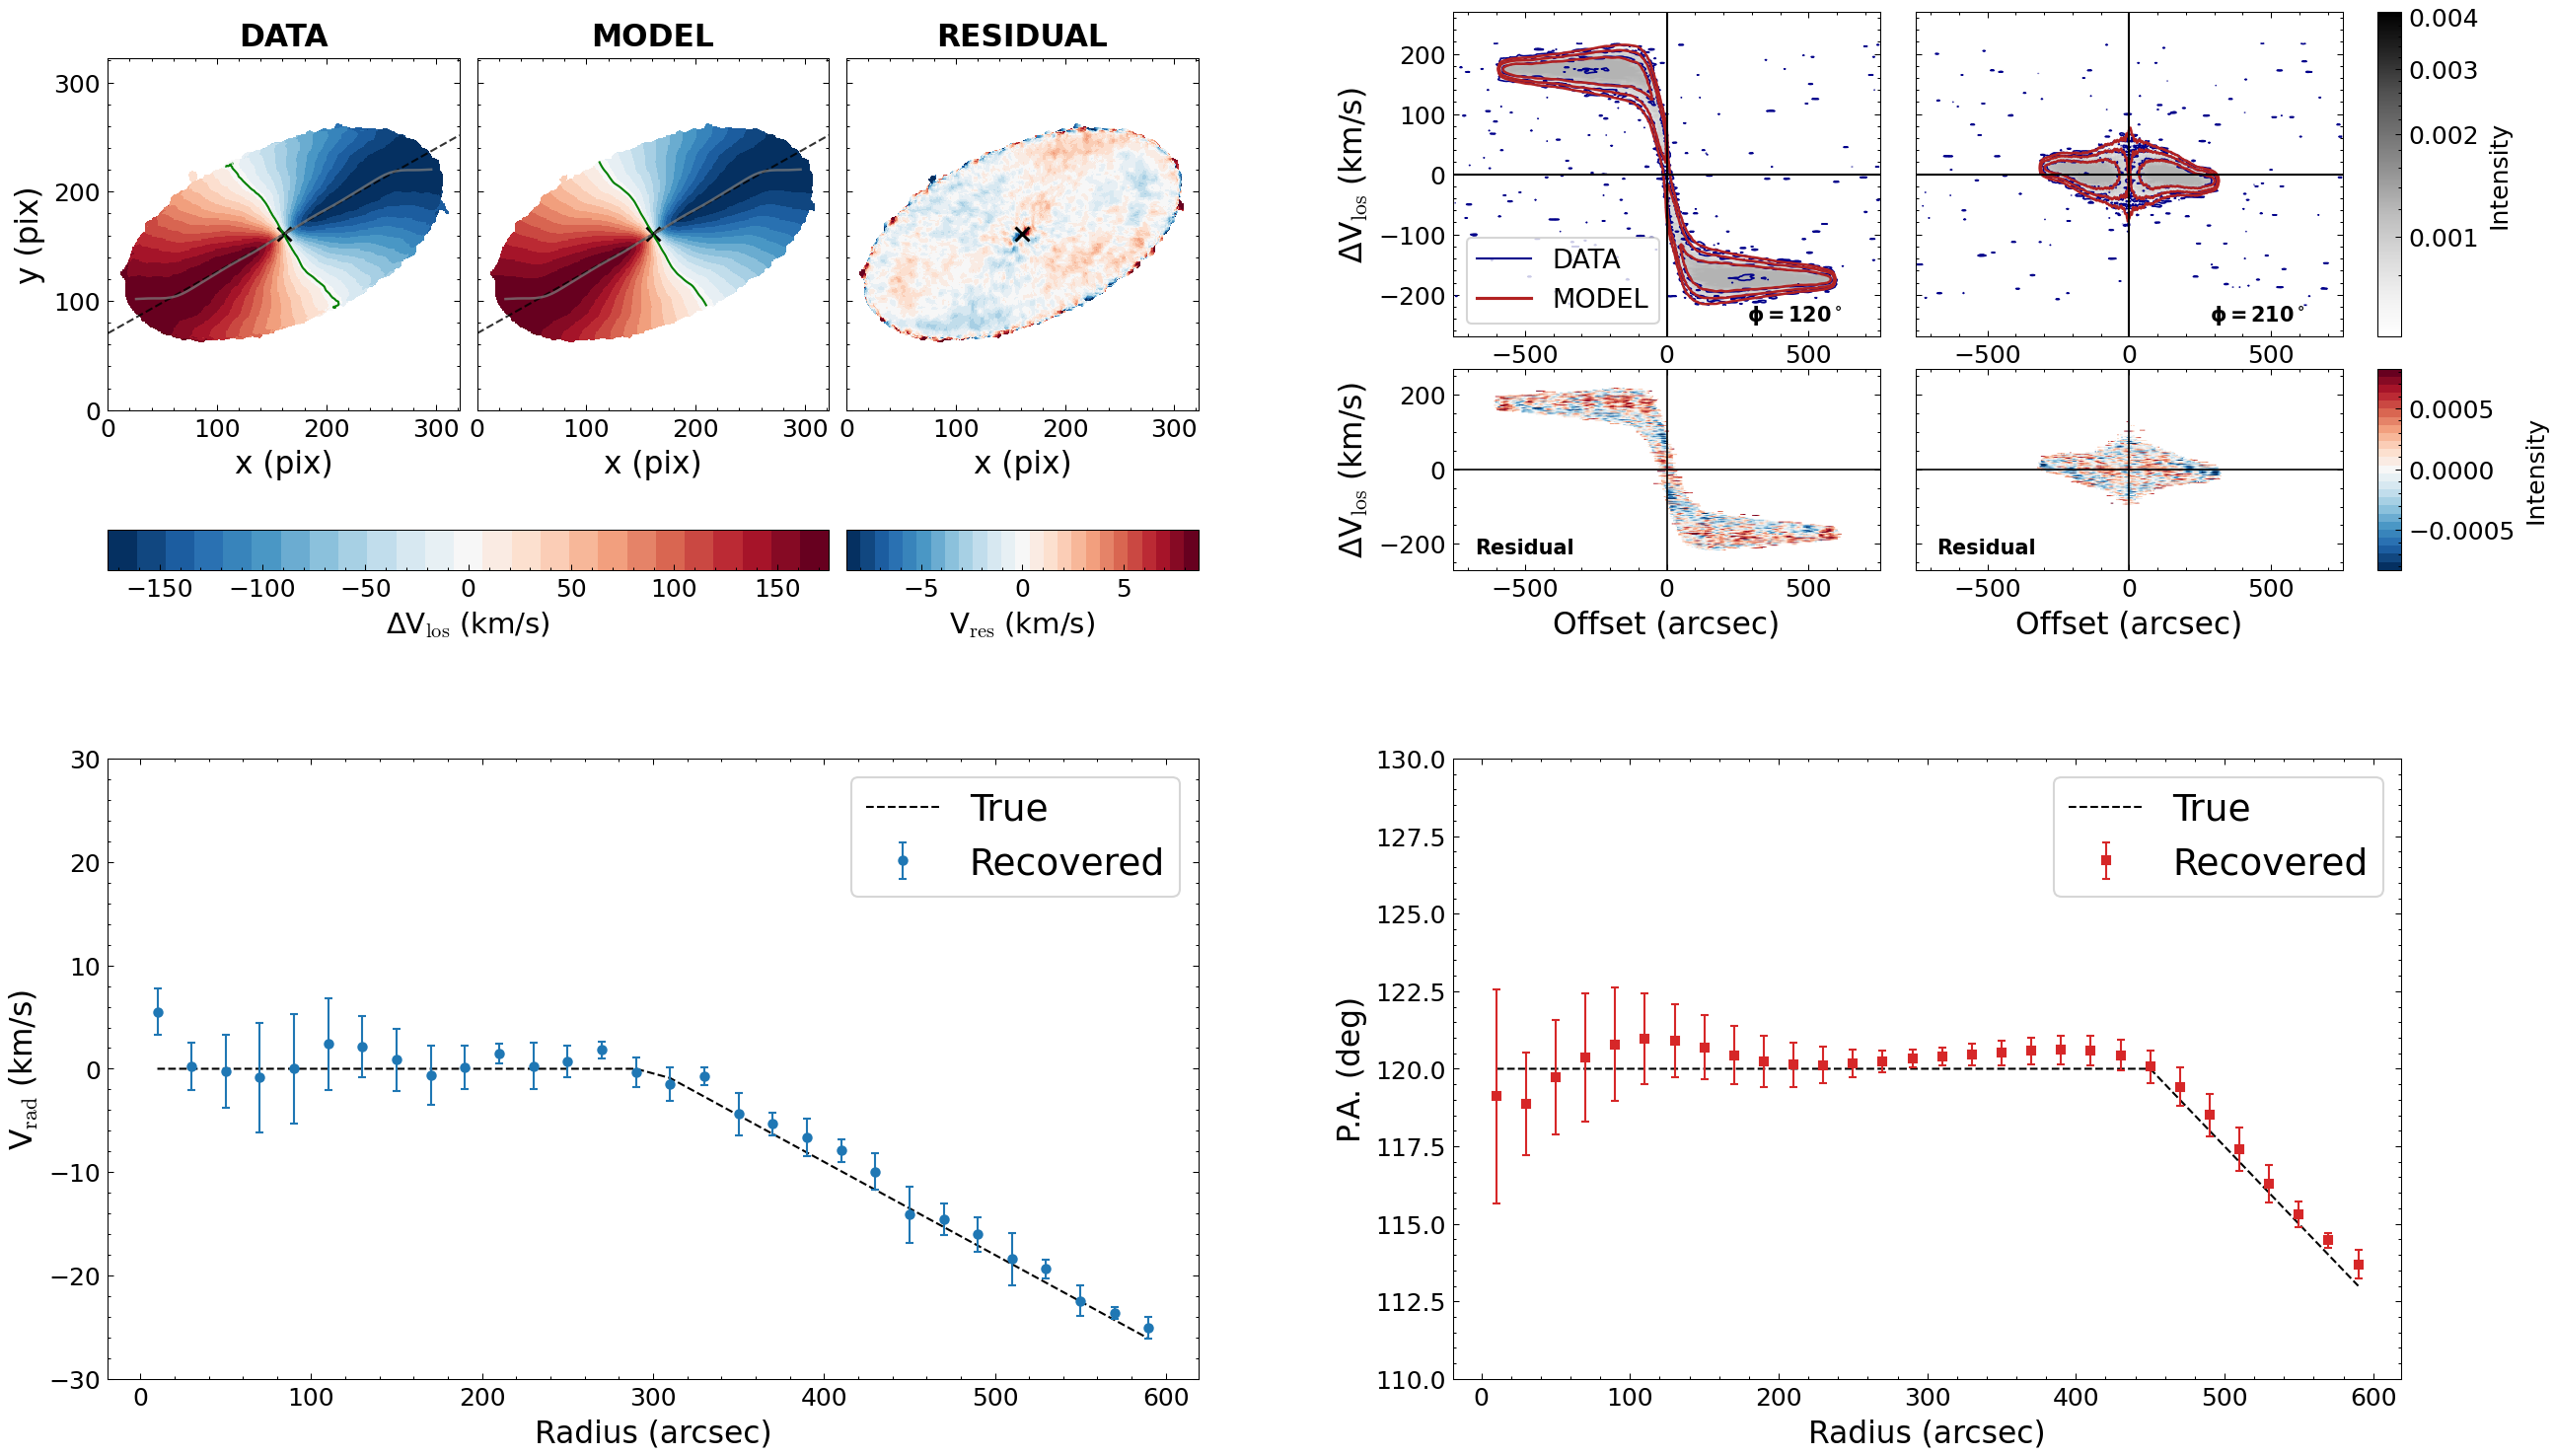

In [5]:
import numpy as np
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.colorbar import ColorbarBase
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

from astropy.io import fits
from astropy.visualization import PercentileInterval, PowerStretch, ImageNormalize
from copy import copy


# ============================================================
# 1. 全局样式
# ============================================================
plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")

plt.rcParams["axes.labelsize"] = 15
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
mpl.rcParams["contour.negative_linestyle"] = "solid"
plt.rc("font", family="sans-serif", size=10)

params = {
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "mathtext.default": "regular",
}
plt.rcParams.update(params)


# ============================================================
# 2. 路径与数据
# ============================================================
RING_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/"
RING_MODEL1123 = RING_BASE + "model1123_processed_60/"
INITIAL_1123 = "/net/dataserver3/data/users/linn/para_initial/test_more_model/model1123/"

galaxy = "ring_v200_R50_PAk0.05_TP450_VRk0.09_TP300_INC60"
outfolder = RING_MODEL1123 + galaxy + "/second_step_check_sinw/"
gname = "SNR10Res10mod"

recorver = pd.read_csv(outfolder + "rings_final2.txt", delimiter=r"\s+")
true_ = pd.read_csv(INITIAL_1123 + galaxy + ".txt", delimiter=r"\s+")
error_ = pd.read_csv(RING_MODEL1123 + galaxy + "/bootstrap_error.txt", delimiter=r"\s+")


# ============================================================
# 3. 读取 ring 参数
# ============================================================
rad, inc, pa, xpos, ypos, vsys = np.genfromtxt(
    outfolder + "rings_final2.txt",
    usecols=(1, 4, 5, 9, 10, 11),
    unpack=True,
)

xcen_m, ycen_m, inc_m, pa_m, vsys_m = np.nanmean(
    (xpos, ypos, inc, pa, vsys),
    axis=1,
)

# 和你的 map 脚本保持一致
xmin, xmax = 39, 361
ymin, ymax = 39, 361

xcen = xcen_m - xmin
ycen = ycen_m - ymin

# 你的模型里 1 pix = 4 arcsec
rad_pix = rad / 4.0

try:
    nr = len(rad_pix)
except TypeError:
    nr = 1


# ============================================================
# 4. 读取 moment map
# ============================================================
f1 = fits.open(outfolder + "/maps/" + gname + "_1mom.fits")
mom1 = f1[0].data[ymin:ymax + 1, xmin:xmax + 1]
f1.close()

mod_file_list = sorted([
    f for f in os.listdir(outfolder + "/maps/")
    if "1mom.fits" in f and ("azim" in f or "local" in f)
])

mom1_mod = fits.open(outfolder + "/maps/" + mod_file_list[0])[0].data[
    ymin:ymax + 1, xmin:xmax + 1
]

maskmap = np.copy(mom1)
maskmap[np.isfinite(mom1)] = 1

ext_map = [0, xmax - xmin, 0, ymax - ymin]


# ============================================================
# 5. 开始画图
# ============================================================
fig = plt.figure(figsize=(20, 12), dpi=150)

gs = GridSpec(
    2, 2,
    figure=fig,
    wspace=0.25,
    hspace=0.32,
    height_ratios=[0.9, 1.0],
    width_ratios=[1.15, 1.0],
)


# ============================================================
# 左上：DATA / MODEL / RESIDUAL velocity map
# ============================================================
gs_tl_main = gs[0, 0].subgridspec(
    2, 1,
    height_ratios=[0.88, 0.08],
    hspace=0.3,
)

# 三列：DATA / MODEL / RESIDUAL
gs_tl_maps = gs_tl_main[0, 0].subgridspec(1, 3, wspace=0.05)

# 两个 colorbar：DATA+MODEL 共用一个，RESIDUAL 单独一个
gs_tl_cb = gs_tl_main[1, 0].subgridspec(
    1, 3,
    width_ratios=[1, 1, 1],
    wspace=0.05,
)

cmap_vel = copy(plt.get_cmap("RdBu_r", 25))
cmap_vel.set_bad("w", 1.0)

# DATA 和 MODEL 使用同一个速度色标
data_for_norm = mom1 - vsys_m
interval = PercentileInterval(99.5)
vmin, vmax = interval.get_limits(data_for_norm)
vabs = max(abs(vmin), abs(vmax))
norm_m = mpl.colors.Normalize(vmin=-vabs, vmax=vabs)

# Residual velocity field: DATA - MODEL
# 注意这里不需要再减 vsys，因为系统速度会抵消
res_mom1 = (mom1 - mom1_mod) * maskmap

finite_res = res_mom1[np.isfinite(res_mom1)]
if len(finite_res) > 0:
    vabs_res = np.nanpercentile(np.abs(finite_res), 99.5)
else:
    vabs_res = 1.0

if not np.isfinite(vabs_res) or vabs_res == 0:
    vabs_res = 1.0

norm_res = mpl.colors.Normalize(vmin=-vabs_res, vmax=vabs_res)

map_list = [
    mom1 - vsys_m,
    mom1_mod - vsys_m,
    res_mom1,
]

titles = ["DATA", "MODEL", "RESIDUAL"]
norm_list = [norm_m, norm_m, norm_res]

# global major axis from mean PA
x_major = np.arange(0, xmax - xmin, 0.1)
y_major = np.tan(np.radians(pa_m - 90.0)) * (x_major - xcen) + ycen

for j, d in enumerate(map_list):
    ax = fig.add_subplot(gs_tl_maps[0, j])

    ax.imshow(
        d * maskmap,
        origin="lower",
        cmap=cmap_vel,
        norm=norm_list[j],
        extent=ext_map,
        aspect="equal",
        interpolation="nearest",
    )

    ax.plot(xcen, ycen, "x", color="black", markersize=7, mew=1.4)

    # DATA 和 MODEL：画零速度线、平均主轴和 PA trace
    if j < 2:
        ax.contour(
            d * maskmap,
            levels=[0],
            colors="green",
            origin="lower",
            extent=ext_map,
            linewidths=1.0,
        )

        # mean major axis
        ax.plot(
            x_major,
            y_major,
            "--",
            color="k",
            linewidth=1.0,
            alpha=0.8,
        )

        # warped PA trace
        if nr > 5 and not np.all(np.diff(pa) == 0):
            x_pix = rad_pix * np.cos(np.radians(pa - 90.0))
            y_pix = rad_pix * np.sin(np.radians(pa - 90.0))

            ax.plot(
                xcen - x_pix,
                ycen - y_pix,
                "-",
                color="grey",
                lw=1.2,
                alpha=0.7,
            )
            ax.plot(
                xcen + x_pix,
                ycen + y_pix,
                "-",
                color="grey",
                lw=1.2,
                alpha=0.7,
            )

    # RESIDUAL：可选画零残差线
    # if j == 2:
    #     try:
    #         ax.contour(
    #             res_mom1,
    #             levels=[0],
    #             colors="k",
    #             origin="lower",
    #             extent=ext_map,
    #             linewidths=0.8,
    #             alpha=0.7,
    #         )
    #     except Exception:
    #         pass

    ax.set_xlim(ext_map[0], ext_map[1])
    ax.set_ylim(ext_map[2], ext_map[3])

    ax.xaxis.set_major_locator(MultipleLocator(100))
    ax.yaxis.set_major_locator(MultipleLocator(100))

    ax.set_xlabel("x (pix)")
    ax.set_title(titles[j], fontsize=15, fontweight="bold")

    if j == 0:
        ax.set_ylabel("y (pix)")
    else:
        ax.set_yticklabels([])

# DATA + MODEL colorbar
ax_cb_vel = fig.add_subplot(gs_tl_cb[0, 0:2])
cb_vel = ColorbarBase(
    ax_cb_vel,
    orientation="horizontal",
    cmap=cmap_vel,
    norm=norm_m,
)
cb_vel.set_label(r"$\Delta V_{\mathrm{los}}$ (km/s)", fontsize=14)
cb_vel.outline.set_linewidth(0.5)

# RESIDUAL colorbar
ax_cb_res = fig.add_subplot(gs_tl_cb[0, 2])
cb_res = ColorbarBase(
    ax_cb_res,
    orientation="horizontal",
    cmap=cmap_vel,
    norm=norm_res,
)
cb_res.set_label(r"$V_{\mathrm{res}}$ (km/s)", fontsize=14)
cb_res.outline.set_linewidth(0.5)


# ============================================================
# 右上：PV diagrams
# ============================================================
gs_tr = gs[0, 1].subgridspec(
    2,
    3,
    height_ratios=[1.0, 0.62],
    width_ratios=[1.0, 1.0, 0.055],
    hspace=0.12,
    wspace=0.12,
)

zmin, zmax = 13, 187

image_maj = fits.open(outfolder + "pvs/" + gname + "_pv_a.fits")
image_min = fits.open(outfolder + "pvs/" + gname + "_pv_b.fits")
mask_pv_maj = fits.open(outfolder + "pvs/" + gname + "mask_pv_a.fits")
mask_pv_min = fits.open(outfolder + "pvs/" + gname + "mask_pv_b.fits")

mod_pv_a = sorted([
    f for f in os.listdir(outfolder + "pvs/")
    if "pv_a_azim.fits" in f or "pv_a_local.fits" in f
])[0]

mod_pv_b = sorted([
    f for f in os.listdir(outfolder + "pvs/")
    if "pv_b_azim.fits" in f or "pv_b_local.fits" in f
])[0]

im_mod_maj = fits.open(outfolder + "pvs/" + mod_pv_a)
im_mod_min = fits.open(outfolder + "pvs/" + mod_pv_b)

head = image_maj[0].header
crpix = head["CRPIX1"]
cdelt = head["CDELT1"]
crval = head["CRVAL1"]

xminpv = int(crpix - 1 - 162)
xmaxpv = int(crpix - 1 + 162)

xmin_wcs = ((xminpv + 1 - 0.5 - crpix) * cdelt + crval) * 3600
xmax_wcs = ((xmaxpv + 1 + 0.5 - crpix) * cdelt + crval) * 3600

zmin_wcs, zmax_wcs = 255.25, -182.25
ext_pv = [xmin_wcs, xmax_wcs, zmin_wcs - vsys_m, zmax_wcs - vsys_m]

cont = 0.000675824
v_levels = np.array([1, 2, 4, 8, 16, 32, 64]) * cont

norm_pv = ImageNormalize(
    vmin=cont,
    vmax=image_maj[0].data.max() * 0.7,
    stretch=PowerStretch(0.5),
)

pv_datas = [
    image_maj[0].data[zmin:zmax + 1, xminpv:xmaxpv + 1],
    image_min[0].data[zmin:zmax + 1, xminpv:xmaxpv + 1],
]

pv_mods = [
    im_mod_maj[0].data[zmin:zmax + 1, xminpv:xmaxpv + 1],
    im_mod_min[0].data[zmin:zmax + 1, xminpv:xmaxpv + 1],
]

pv_masks = [
    mask_pv_maj[0].data[zmin:zmax + 1, xminpv:xmaxpv + 1],
    mask_pv_min[0].data[zmin:zmax + 1, xminpv:xmaxpv + 1],
]
pv_masks = [
    np.where(np.isfinite(mask) & (mask != 0), 1.0, np.nan)
    for mask in pv_masks
]
pv_residuals = [
    (data - model) * mask
    for data, model, mask in zip(pv_datas, pv_mods, pv_masks)
]
pv_resid_values = np.concatenate([
    resid[np.isfinite(resid)] for resid in pv_residuals
])

# symmetric normalization around zero for residuals
vabs_pv_res = np.nanpercentile(
    np.abs(pv_resid_values),
    99.0
)

if not np.isfinite(vabs_pv_res) or vabs_pv_res == 0:
    vabs_pv_res = 1.0

cmap_pv_res = copy(plt.get_cmap("RdBu_r", 25))
cmap_pv_res.set_bad("white", 1.0)

norm_pv_res = mpl.colors.Normalize(
    vmin=-vabs_pv_res,
    vmax=vabs_pv_res,
)

phi_labels = [r"$\phi = 120^\circ$", r"$\phi = 210^\circ$"]

for i in range(2):
    ax = fig.add_subplot(gs_tr[0, i])

    ax.imshow(
        pv_datas[i],
        origin="lower",
        cmap="Greys",
        norm=norm_pv,
        extent=ext_pv,
        aspect="auto",
        alpha=0.3,
    )

    ax.contour(
        pv_datas[i],
        v_levels,
        origin="lower",
        linewidths=0.8,
        colors="#00008B",
        extent=ext_pv,
    )

    ax.contour(
        pv_mods[i],
        v_levels,
        origin="lower",
        linewidths=1.2,
        colors="#B22222",
        extent=ext_pv,
    )

    ax.axhline(y=0, color="black", lw=1)
    ax.axvline(x=0, color="black", lw=1)

    ax.set_ylim(-270, 270)
    ax.set_xlabel("Offset (arcsec)")

    ax.text(
        0.8,
        0.05,
        phi_labels[i],
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        ha="center",
    )

    if i == 0:
        ax.set_ylabel(r"$\Delta V_{\mathrm{los}}$ (km/s)")

        # 如果你前面定义了 radius_pts 和 vlos_pts，就叠加旋转曲线点
        if "radius_pts" in globals() and "vlos_pts" in globals():
            ax.plot(
                radius_pts,
                vlos_pts,
                "y.",
                markersize=7,
                markeredgecolor="olive",
                alpha=0.6,
            )

        legend_elements = [
            Line2D([0], [0], color="#00008B", lw=1, label="DATA"),
            Line2D([0], [0], color="#B22222", lw=1.5, label="MODEL"),
        ]
        ax.legend(
            handles=legend_elements,
            loc="lower left",
            frameon=True,
            fontsize=13,
        )
    else:
        ax.set_yticklabels([])

    ax.set_xlim(min(xmin_wcs, xmax_wcs), max(xmin_wcs, xmax_wcs))

    ax_res = fig.add_subplot(gs_tr[1, i])
    ax_res.imshow(
        pv_residuals[i],
        origin="lower",
        cmap=cmap_pv_res,
        norm=norm_pv_res,
        extent=ext_pv,
        aspect="auto",
    )

    ax_res.axhline(y=0, color="black", lw=0.8)
    ax_res.axvline(x=0, color="black", lw=0.8)

    ax_res.set_ylim(-270, 270)
    ax_res.set_xlim(min(xmin_wcs, xmax_wcs), max(xmin_wcs, xmax_wcs))
    ax_res.set_xlabel("Offset (arcsec)")
    ax_res.text(
        0.05,
        0.08,
        "Residual",
        transform=ax_res.transAxes,
        fontsize=10,
        fontweight="bold",
        ha="left",
    )

    if i == 0:
        ax_res.set_ylabel(r"$\Delta V_{\mathrm{los}}$ (km/s)")
    else:
        ax_res.set_yticklabels([])

ax_cb_pv = fig.add_subplot(gs_tr[0, 2])
cb_pv = ColorbarBase(
    ax_cb_pv,
    orientation="vertical",
    cmap=plt.get_cmap("Greys"),
    norm=norm_pv,
)
cb_pv.set_label("Intensity", fontsize=12)
cb_pv.outline.set_linewidth(0.5)

ax_cb_pv_res = fig.add_subplot(gs_tr[1, 2])
cb_pv_res = ColorbarBase(
    ax_cb_pv_res,
    orientation="vertical",
    cmap=cmap_pv_res,
    norm=norm_pv_res,
)

cb_pv_res.set_label("Intensity", fontsize=12)
cb_pv_res.outline.set_linewidth(0.5)


# ============================================================
# 左下：VRAD
# ============================================================
ax_vrad = fig.add_subplot(gs[1, 0])

ax_vrad.plot(
    true_["RAD(arcs)"],
    true_["VRAD(km/s)"],
    "k--",
    label="True",
)

ax_vrad.errorbar(
    recorver["RAD(arcs)"],
    recorver["VRAD(km/s)"],
    yerr=error_["VRADerror(km/s)"],
    fmt="o",
    color="tab:blue",
    label="Recovered",
    markersize=4,
    capsize=2,
)

ax_vrad.set_xlabel("Radius (arcsec)")
ax_vrad.set_ylabel(r"$V_{\mathrm{rad}}$ (km/s)")
ax_vrad.legend(fontsize=18, frameon=True)
ax_vrad.set_ylim(-30, 30)


# ============================================================
# 右下：PA
# ============================================================
ax_pa = fig.add_subplot(gs[1, 1])

ax_pa.plot(
    true_["RAD(arcs)"],
    true_["P.A.(deg)"],
    "k--",
    label="True",
)

ax_pa.errorbar(
    recorver["RAD(arcs)"],
    recorver["P.A.(deg)"],
    yerr=error_["P.A.error(deg)"],
    fmt="s",
    color="tab:red",
    label="Recovered",
    markersize=4,
    capsize=2,
)

ax_pa.set_xlabel("Radius (arcsec)")
ax_pa.set_ylabel("P.A. (deg)")
ax_pa.legend(fontsize=18, frameon=True)
ax_pa.set_ylim(120 - 10, 120 + 10)


# ============================================================
# 保存
# ============================================================
plt.tight_layout()

plt.savefig(
    "single_galaxy_error_with_maps_pv_2_residual.pdf",
    bbox_inches="tight",
)

plt.show()


# Close FITS files
image_maj.close()
image_min.close()
mask_pv_maj.close()
mask_pv_min.close()
im_mod_maj.close()
im_mod_min.close()
